# The ODE-Constrained Bayesian Optimizer
### Architecture
In this script, we will simulate a state-of-the-art bioprocess optimization loop. We will replace the pure mathematical polynomial from our earlier chapters with a constrained, mechanistic ODE system.\
Here is how the components will work together:
1. The Inputs (DoE Bioprocess Simulation): We will define a DoE search space for Temperature and pH.
2. The "Grey Box" Link (Physics-Informed Neural Network): We will create a function that acts as our trained Machine Learning model. It will translate environmental conditions (Temp, pH) directly into biological kinetic parameters ($\mu_{max}$ and $\beta$).
3. The "White Box" Engine (Ordinary Differential Equations --ODE): We will feed those predicted parameters into the Monod and Luedeking-Piret ODEs to simulate a full 14-day bioreactor run, ensuring the system obeys the laws of mass conservation.
4. The Navigator (In Silico Optimization): The Bayesian Optimizer will blindly guess Temp and pH, run the full 14-day ODE simulation, look at the final Day 14 Titer, and use its Gaussian Process to hunt for the optimal setup.

## 💻 The Capstone Script: The ODE-Constrained Bayesian Optimizer

In [3]:
# Import dependencies
import numpy as np
from scipy.integrate import odeint
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
import matplotlib.pyplot as plt

In [10]:
# ==========================================
# 1. THE "GREY BOX" LINK (Environment to Kinetics)
# ==========================================

def environmental_kinetics(temp, ph):
    """
    In a real CRO, this function is a trained PyTorch Neural Network.
    It translates physical bioreactor dials into biological kinetic rates.
    We are simulating that network's behavior here with physical boundaries.
    """
    # Simulate a biological peak: Cells grow best at 37 C, and secrete best at pH 7.0
    # Deviations from these ideals lower the kinetic rates.
    mu_max = 0.8 - 0.05*(temp-37.0)**2
    beta = 0.1 - 0.02*(ph - 7.0)**2

    # BIOLOGICAL CONSTRAINTS: Rates cannot be negative. If they drop below 0, the cell is dead.
    mu_max = max(0.001, mu_max)
    beta = max(0.0, beta)

    return mu_max, beta

# ==========================================
# 2. THE "WHITE BOX" ENGINE (The Mechanistic ODEs)
# ==========================================

def biological_ode(y, t, mu_max, beta):
    """ The fundamental laws of mass balance from ODE section. """
    X, S, P = y

    Ks = 0.5     # Constant affinity
    Y_xs = 0.4   # Constant yield
    alpha= 0.01  # Small growth-associated production

    # Monod constraint: Stop growing if glucose is gone
    if S <= 0:
        S = 0
        mu = 0
    else:
        mu = mu_max * (S/(Ks+S))

    dXdt = mu * X
    dSdt = -(1/Y_xs) * dXdt
    dPdt = alpha * dXdt + beta * X

    return [dXdt, dSdt, dPdt]

# ==========================================
# 3. THE OBJECTIVE FUNCTION (The Bioreactor Simulation)
# ==========================================
# Define the DoE Search Space for the Bayesian Optimizer
space = [
    Real(32.0, 39.0, name='temp'),
    Real(6.5, 7.5, name='ph')
]

@use_named_args(space)
def run_virtual_bioreactor(**params):
    """ This function runs the full 14-day simulation for a given Temp and pH. """
    T = params['temp']
    pH = params['ph']

    # Step A: Translate Environment to Kinetics (The Hybrid Step)
    mu_max, beta = environmental_kinetics(T, pH)

    # Step B: Setup initial Conditions for a 14-Day Batch
    y0 = [0.1, 10.0, 0.0]  # [Cells(g/L), Glucose(g/L), Titer(g/L)]
    time_days = np.linspace(0, 14, 100) # 100 points in 14 days

    # Step C: Run the ODE Physics Engine
    solution = odeint(biological_ode, y0, time_days, args=(mu_max, beta))

    # Extract the final Day 14 Titer (Index 2 is P, the last row is Day 14)
    final_titer = solution[-1, 2]

    # Return negative titer because skopt minimizes by default
    return -final_titer

In [11]:
# ==========================================
# 4. THE NAVIGATOR (Bayesian Optimization)
# ==========================================
print("🚀 Starting ODE-Constrained Bayesian Optimization...")
print("The AI is running 25 virtual 14-day bioreactors to map the manifold...\n")

res = gp_minimize(
    func=run_virtual_bioreactor,
    dimensions=space,
    acq_func='EI', # Expected improvement
    n_calls=25,     # Total experimental budget
    random_state=5
)

best_temp = res.x[0]
best_ph = res.x[1]
best_titer = -res.fun

print(f"🎯 OPTIMIZATION COMPLETE!")
print(f"Maximum Predicted Titer: {best_titer:.3f} g/L")
print(f"Optimal Parameters Found: Temp = {best_temp:.2f} °C, pH = {best_ph:.3f}")

🚀 Starting ODE-Constrained Bayesian Optimization...
The AI is running 25 virtual 14-day bioreactors to map the manifold...

🎯 OPTIMIZATION COMPLETE!
Maximum Predicted Titer: 4.282 g/L
Optimal Parameters Found: Temp = 37.14 °C, pH = 7.000


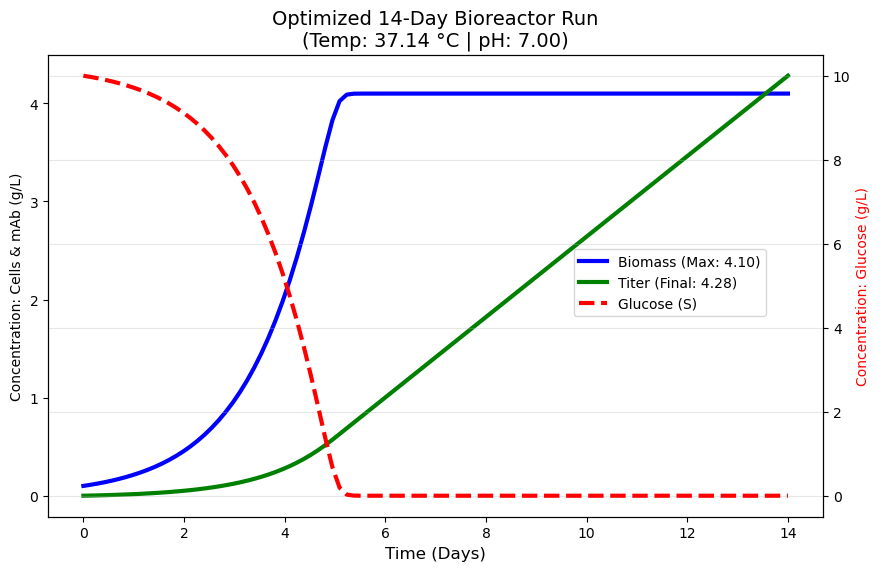

In [15]:
# ==========================================
# 5. VISUALIZING THE WINNING RUN
# ==========================================
# Let's run the ODE one final time at the absolute best settings to plot the biological curves
opt_mu, opt_beta = environmental_kinetics(best_temp, best_ph)
time_days = np.linspace(0, 14, 100)
best_solution = odeint(biological_ode, [0.1, 10.0, 0.0], time_days, args=(opt_mu, opt_beta))

X_sim = best_solution[:, 0]
S_sim = best_solution[:, 1]
P_sim = best_solution[:, 2]

fig, ax1 =plt.subplots(figsize=(10, 6))
ax1.plot(time_days, X_sim, 'b-', linewidth=3, label=f'Biomass (Max: {max(X_sim):.2f})')
ax1.plot(time_days, P_sim, 'g-', linewidth=3, label=f'Titer (Final: {best_titer:.2f})')
ax1.set_xlabel('Time (Days)', fontsize=12)
ax1.set_ylabel('Concentration: Cells & mAb (g/L)', color='black')

ax2 = ax1.twinx()
ax2.plot(time_days, S_sim, 'r--', linewidth=3, label='Glucose (S)')
ax2.set_ylabel('Concentration: Glucose (g/L)', color='red')

plt.title(f'Optimized 14-Day Bioreactor Run\n(Temp: {best_temp:.2f} °C | pH: {best_ph:.2f})', fontsize=14)
fig.legend(loc="center right", bbox_to_anchor=(0.85, 0.5))
plt.grid(alpha=0.3)
plt.show()